**MK Rekayasa Fitur**

**Topik:** Seleksi Fitur
- **Dataset**: Data Gambar

**Galih Hermawan. Prodi Teknik Informatika. UNIKOM**

---

# 1. Filter Histogram Warna

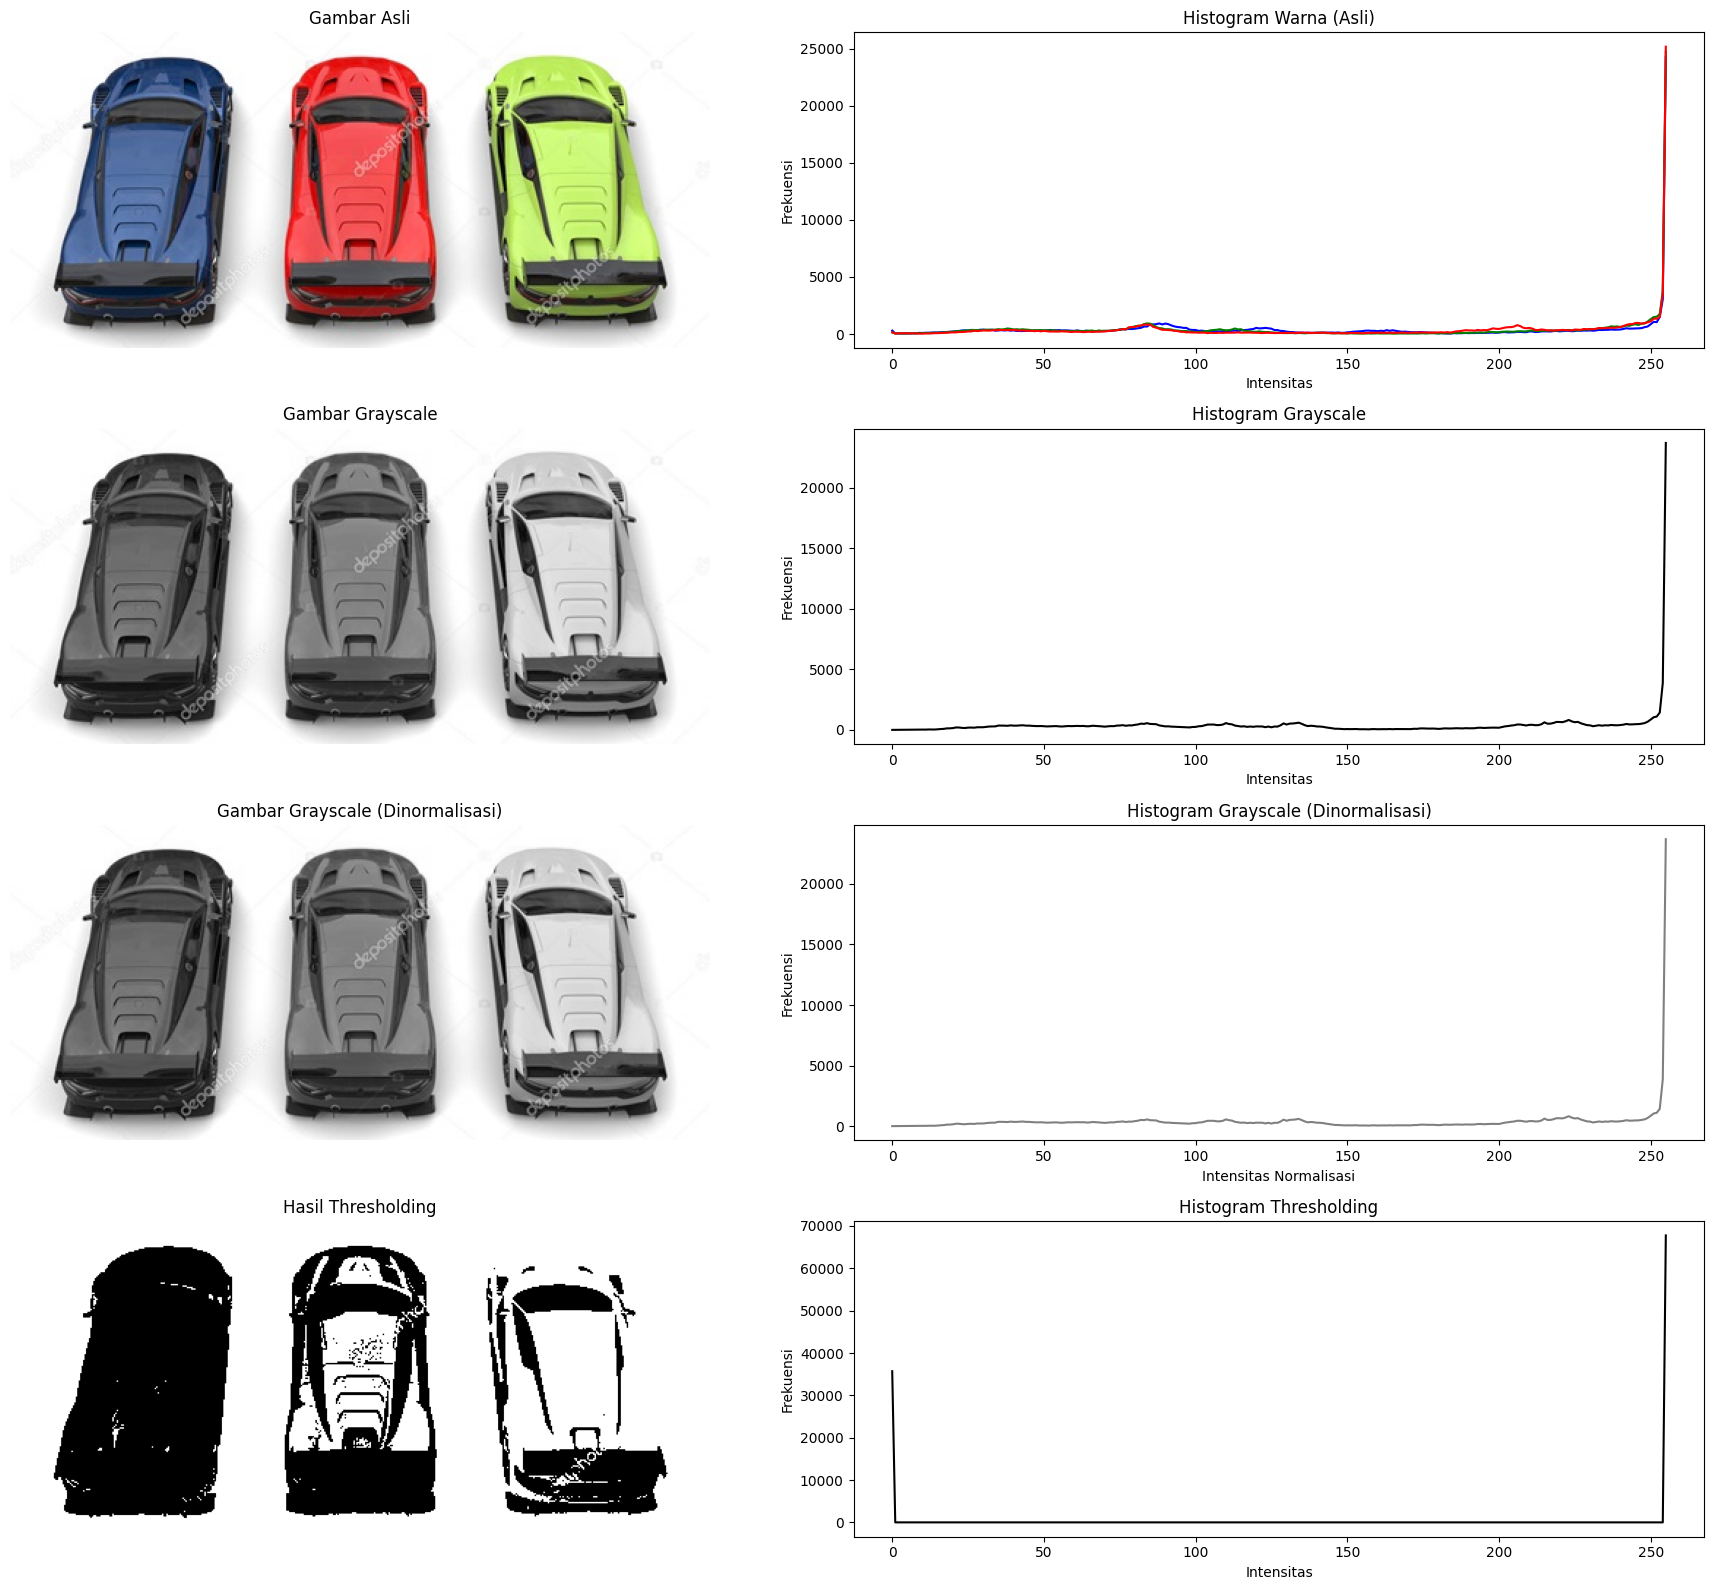

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
gambar = cv2.imread('bunga.jpg')
#gambar = cv2.imread('apel_2.jpg')
#gambar = cv2.imread('apel_6.jpg')
#gambar = cv2.imread('ubin_warna.png')
gambar = cv2.imread('mobil_3.jpg')

# Konversi ke citra grayscale
gambar_gray = cv2.cvtColor(gambar, cv2.COLOR_BGR2GRAY)

# Normalisasi nilai piksel ke rentang [0, 1]
gambar_gray_norm = gambar_gray.astype(np.float32) / 255.0

# Thresholding citra grayscale
_, gambar_threshold = cv2.threshold(gambar_gray, 127, 255, cv2.THRESH_BINARY)

# Hitung histogram warna pada gambar asli
hist_b, bins_b = np.histogram(gambar[:,:,0].ravel(), 256, [0,256])
hist_g, bins_g = np.histogram(gambar[:,:,1].ravel(), 256, [0,256])
hist_r, bins_r = np.histogram(gambar[:,:,2].ravel(), 256, [0,256])

# Hitung histogram warna pada citra grayscale
hist_gray, bins_gray = np.histogram(gambar_gray.ravel(), 256, [0,256])

# Hitung histogram warna pada citra grayscale yang sudah dinormalisasi
hist_gray_norm, bins_gray_norm = np.histogram(gambar_gray_norm.ravel(), 256, [0,1])

# Hitung histogram warna pada citra hasil thresholding
hist_threshold, bins_threshold = np.histogram(gambar_threshold.ravel(), 256, [0,256])

# Plot histogram dalam satu bingkai
plt.figure(figsize=(18, 16))

# Gambar asli dan histogramnya
plt.subplot(4, 2, 1)
plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(4, 2, 2)
plt.plot(hist_b, color='blue')
plt.plot(hist_g, color='green')
plt.plot(hist_r, color='red')
plt.title('Histogram Warna (Asli)')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

# Gambar grayscale dan histogramnya
plt.subplot(4, 2, 3)
plt.imshow(gambar_gray, cmap='gray')
plt.title('Gambar Grayscale')
plt.axis('off')

plt.subplot(4, 2, 4)
plt.plot(hist_gray, color='black')
plt.title('Histogram Grayscale')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

# Gambar hasil normalisasi dan histogramnya
plt.subplot(4, 2, 5)
plt.imshow(gambar_gray_norm, cmap='gray')
plt.title('Gambar Grayscale (Dinormalisasi)')
plt.axis('off')

plt.subplot(4, 2, 6)
plt.plot(hist_gray_norm, color='gray')
plt.title('Histogram Grayscale (Dinormalisasi)')
plt.xlabel('Intensitas Normalisasi')
plt.ylabel('Frekuensi')

# Gambar hasil thresholding dan histogramnya
plt.subplot(4, 2, 7)
plt.imshow(gambar_threshold, cmap='gray')
plt.title('Hasil Thresholding')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.plot(hist_threshold, color='black')
plt.title('Histogram Thresholding')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Konversi gambar ke ruang warna HUE (Hue-Saturation-Value) umumnya dilakukan dalam konteks filter histogram warna karena ruang warna HUE memisahkan informasi warna dari informasi kecerahan (intensitas). Ini memungkinkan kita untuk lebih fokus pada distribusi warna sebenarnya dalam gambar, tanpa dipengaruhi oleh variasi dalam kecerahan.

Berikut adalah alasan mengapa konversi ke ruang warna HUE sering digunakan dalam analisis histogram warna:

- Memisahkan Informasi Warna dan Kecerahan: Dalam ruang warna HUE, komponen Hue (H) mewakili informasi warna secara langsung, sementara komponen Saturation (S) dan Value (V) mewakili informasi kecerahan dan saturasi. Dengan memisahkan informasi warna dari kecerahan, kita dapat lebih fokus pada distribusi warna sebenarnya dalam gambar.

- Invarian Terhadap Kecerahan: Distribusi intensitas piksel dalam ruang warna HUE biasanya tidak dipengaruhi oleh variasi dalam kecerahan gambar. Ini berarti bahwa histogram HUE akan tetap konsisten terhadap perubahan kecerahan gambar, sehingga lebih cocok untuk mengekstraksi fitur warna yang tidak bergantung pada kecerahan.

- Perwakilan Warna yang Lebih Berarti: Hue adalah komponen yang mewakili "nuansa" atau "jenis" warna, yang membuatnya lebih bermakna dalam analisis warna. Dengan menggunakan komponen Hue, kita dapat dengan lebih baik menangkap perbedaan antara warna-warna yang berbeda dalam gambar.

- Keandalan pada Gambar Berwarna: Konversi ke ruang warna HUE memungkinkan kita untuk menghasilkan histogram warna yang lebih konsisten dan andal, terutama pada gambar-gambar dengan variasi kecerahan yang besar atau dengan pencahayaan yang berbeda-beda.

Dengan demikian, konversi ke ruang warna HUE sering kali merupakan pilihan yang baik dalam analisis histogram warna, terutama ketika fokus utama adalah pada distribusi warna sebenarnya dalam gambar.

---
# 2. Filter Tekstur

Metode Gabor Filter adalah teknik pengolahan citra yang menggunakan filter Gabor untuk mendeteksi tekstur dalam gambar. Berikut adalah ringkasan singkat tentang metode Gabor Filter:

- Definisi: Filter Gabor adalah filter linier yang digunakan untuk menganalisis frekuensi spasial dalam citra. Filter ini mengambil bentuk sinusoidal yang diubah dengan Gaussian.

- Keunggulan: Metode Gabor Filter memiliki beberapa keunggulan, termasuk kemampuannya untuk mendeteksi tekstur dengan berbagai orientasi dan skala, serta kemampuannya untuk mengatasi efek cahaya dan bayangan pada gambar.

- Struktur Filter: Filter Gabor memiliki dua komponen utama: Gaussian (untuk menentukan lokasi dan frekuensi) dan sinusoidal (untuk menentukan orientasi). Filter Gabor dapat diatur dengan berbagai parameter, termasuk frekuensi, orientasi, dan lebar bandwidth.

- Penggunaan: Metode Gabor Filter banyak digunakan dalam berbagai aplikasi pengolahan citra, termasuk deteksi tepi, segmentasi, ekstraksi fitur, dan klasifikasi. Ini sering digunakan dalam aplikasi penglihatan komputer untuk mengenali objek atau pola dalam gambar.

- Implementasi: Implementasi filter Gabor melibatkan pembuatan kernel Gabor dengan parameter yang sesuai, seperti frekuensi, orientasi, dan lebar bandwidth. Kernel Gabor kemudian diterapkan pada gambar menggunakan operasi konvolusi untuk menghasilkan respons filter.

- Hasil: Hasil dari penggunaan filter Gabor adalah citra yang ditingkatkan dengan penekanan tekstur atau fitur tertentu dalam gambar, yang memungkinkan analisis lebih lanjut atau pengenalan objek.

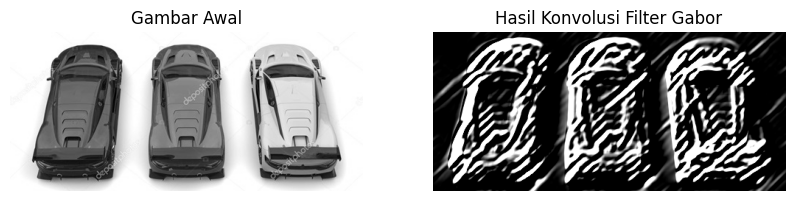

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi untuk membuat filter Gabor
def buat_filter_gabor(ksize, sigma, theta, lambda_, gamma):
    phi = 0.5 * np.pi
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    # Komponen x dan y untuk filter Gabor
    x, y = np.meshgrid(np.arange(-ksize[0]//2 + 1, ksize[0]//2 + 1), 
                       np.arange(-ksize[1]//2 + 1, ksize[1]//2 + 1))
    
    # Rotasi filter Gabor
    x_theta = x * cos_theta + y * sin_theta
    y_theta = -x * sin_theta + y * cos_theta
    
    # Kernel Gabor
    gb = np.exp(-0.5 * (x_theta**2 + gamma**2 * y_theta**2) / sigma**2) * np.cos(2 * np.pi / lambda_ * x_theta + phi)
    return gb

# Load gambar
gambar = cv2.imread('mobil_3.jpg', cv2.IMREAD_GRAYSCALE)

# Ukuran filter Gabor
ksize = (21, 21)

# Membuat filter Gabor
theta = np.pi / 4  # Sudut rotasi filter Gabor
sigma = 5  # Standar deviasi filter Gabor
lambda_ = 10  # Panjang gelombang filter Gabor
gamma = 0.5  # Aspek rasio filter Gabor
filter_gabor = buat_filter_gabor(ksize, sigma, theta, lambda_, gamma)

# Melakukan konvolusi dengan filter Gabor
hasil_konvolusi = cv2.filter2D(gambar, -1, filter_gabor)

# Menampilkan gambar asli dan hasil konvolusi
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gambar, cmap='gray')
plt.title('Gambar Awal')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_konvolusi, cmap='gray')
plt.title('Hasil Konvolusi Filter Gabor')
plt.axis('off')

plt.show()


---
# 3. Filter Tepi

1. **Filter Tepi Canny**:
   - **Definisi**: Filter tepi Canny adalah metode populer untuk mendeteksi tepi dalam citra. Ini menggunakan algoritma multi-tahap yang melibatkan deteksi tepi dengan menggunakan operator gradien, penapisan non-maksimum, dan ambang batas (thresholding) ganda.
   - **Keunggulan**: Canny adalah salah satu metode yang paling umum digunakan untuk deteksi tepi karena memiliki sensitivitas yang tinggi terhadap tepi yang sebenarnya dan menghasilkan tepi yang tipis dan terinterpolasi dengan baik.
   - **Implementasi**: Canny beroperasi dalam beberapa tahap, termasuk menghitung gradien citra, menemukan piksel tepi yang signifikan, menghapus piksel yang tidak relevan, dan menerapkan ambang batas ganda untuk menghasilkan tepi akhir.
   - **Penggunaan**: Canny sering digunakan dalam berbagai aplikasi pengolahan citra, termasuk visi komputer, pengenalan pola, dan analisis citra medis.

2. **Filter Tepi Sobel**:
   - **Definisi**: Filter tepi Sobel adalah operator gradien yang digunakan untuk mendeteksi tepi dalam citra. Ini menghitung gradien citra dalam arah horizontal dan vertikal menggunakan kernel Sobel.
   - **Keunggulan**: Sobel adalah metode yang sederhana dan efektif untuk deteksi tepi, sering digunakan karena komputasinya yang cepat dan hasil yang cukup baik dalam banyak kasus.
   - **Implementasi**: Sobel menggunakan dua kernel konvolusi, satu untuk mendeteksi gradien dalam arah horizontal dan satu untuk mendeteksi gradien dalam arah vertikal. Hasil dari kedua operasi ini digabungkan untuk menghasilkan magnitudo gradien.
   - **Penggunaan**: Sobel umumnya digunakan sebagai komponen dalam algoritma deteksi tepi yang lebih kompleks atau sebagai alat dasar dalam analisis citra untuk mengekstraksi fitur tepi.

Kedua filter tepi ini digunakan secara luas dalam berbagai aplikasi pengolahan citra dan visi komputer untuk mendeteksi tepi dan mengekstraksi fitur tepi dalam citra. Pemilihan antara Canny dan Sobel tergantung pada kebutuhan spesifik dari tugas yang dihadapi dan karakteristik dari gambar yang dianalisis.

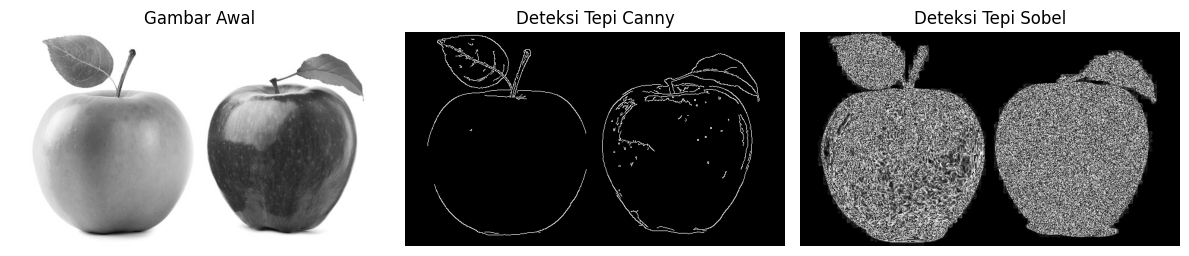

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
gambar = cv2.imread('apel_2.jpg', cv2.IMREAD_GRAYSCALE)

# Deteksi tepi dengan metode Canny
gambar_canny = cv2.Canny(gambar, 100, 200)

# Deteksi tepi dengan metode Sobel
gambar_sobelx = cv2.Sobel(gambar, cv2.CV_64F, 1, 0, ksize=5)
gambar_sobely = cv2.Sobel(gambar, cv2.CV_64F, 0, 1, ksize=5)
gambar_sobel = np.sqrt(gambar_sobelx**2 + gambar_sobely**2)
gambar_sobel = np.uint8(gambar_sobel)

# Tampilkan gambar asli, Canny, dan Sobel
plt.figure(figsize=(12, 4))

# Gambar asli
plt.subplot(1, 3, 1)
plt.imshow(gambar, cmap='gray')
plt.title('Gambar Awal')
plt.axis('off')

# Deteksi tepi Canny
plt.subplot(1, 3, 2)
plt.imshow(gambar_canny, cmap='gray')
plt.title('Deteksi Tepi Canny')
plt.axis('off')

# Deteksi tepi Sobel
plt.subplot(1, 3, 3)
plt.imshow(gambar_sobel, cmap='gray')
plt.title('Deteksi Tepi Sobel')
plt.axis('off')

plt.tight_layout()
plt.show()


---
# 4. Filter Transformasi Spasial 

Filter transformasi spasial adalah teknik pengolahan citra yang melibatkan penerapan kernel konvolusi pada gambar asli untuk melakukan operasi seperti penghalusan, penajaman, deteksi tepi, dan banyak lagi. 

**a. Filter Penghalusan (Smoothing):**

Penghalusan digunakan untuk mengurangi noise dalam gambar atau meratakan detail untuk menciptakan efek yang lebih halus.

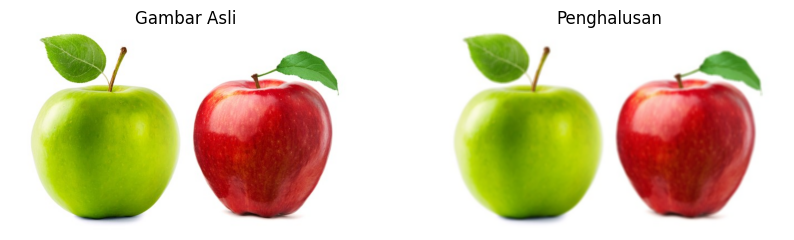

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
gambar = cv2.imread('apel_2.jpg')

# Filter penghalusan (blurring)
kernel_penghalusan = np.ones((5, 5), np.float32) / 25
gambar_penghalusan = cv2.filter2D(gambar, -1, kernel_penghalusan)

# Tampilkan gambar asli dan hasil penghalusan
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gambar_penghalusan, cv2.COLOR_BGR2RGB))
plt.title('Penghalusan')
plt.axis('off')

plt.show()


**b. Filter Penajaman (Sharpening):**

Penajaman digunakan untuk meningkatkan detail dalam gambar atau membuat tepi menjadi lebih tajam.

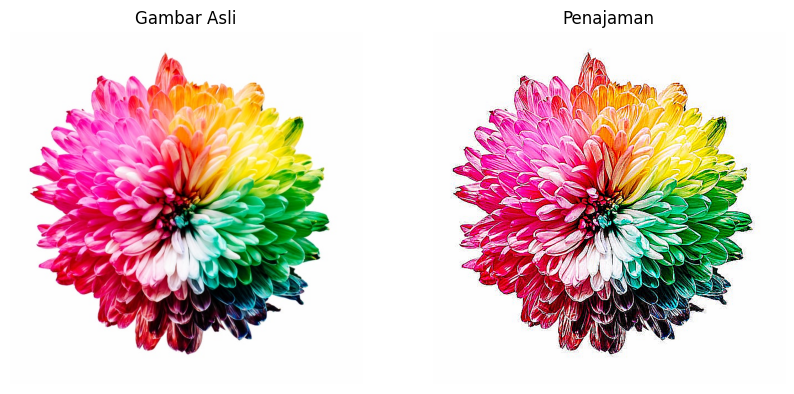

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
gambar = cv2.imread('bunga.jpg')

# Filter penajaman (sharpening)
kernel_penajaman = np.array([[-1, -1, -1],
                             [-1, 9, -1],
                             [-1, -1, -1]])
gambar_penajaman = cv2.filter2D(gambar, -1, kernel_penajaman)

# Tampilkan gambar asli dan hasil penajaman
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gambar_penajaman, cv2.COLOR_BGR2RGB))
plt.title('Penajaman')
plt.axis('off')

plt.show()

# 4. Filter Transformasi Frekuensi

Transformasi frekuensi adalah teknik pengolahan citra yang melibatkan konversi gambar dari domain spasial ke domain frekuensi, di mana informasi tentang frekuensi dan arahnya lebih mudah diakses. Salah satu transformasi frekuensi yang umum digunakan adalah Transformasi Fourier.

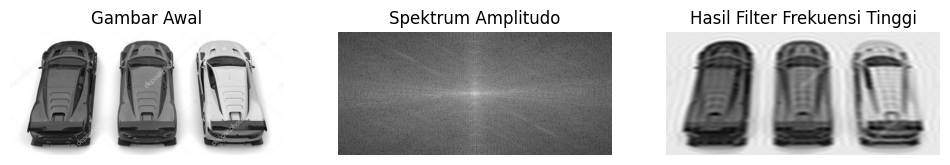

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
gambar = cv2.imread('mobil_3.jpg', cv2.IMREAD_GRAYSCALE)

# Transformasi Fourier
gambar_transformasi = np.fft.fft2(gambar)
gambar_transformasi_shifted = np.fft.fftshift(gambar_transformasi)
spektrum_amplitudo = 20 * np.log(np.abs(gambar_transformasi_shifted))

# Filter high-pass (penyorotan frekuensi tinggi)
rows, cols = gambar.shape
center_row, center_col = rows // 2, cols // 2
D = 30  # Jarak dari pusat frekuensi
mask = np.zeros((rows, cols), np.uint8)
mask[center_row - D:center_row + D, center_col - D:center_col + D] = 1

# Aplikasikan filter ke dalam domain frekuensi
gambar_transformasi_shifted_filtered = gambar_transformasi_shifted * mask

# Transformasi balik
gambar_hasil = np.fft.ifftshift(gambar_transformasi_shifted_filtered)
gambar_hasil = np.fft.ifft2(gambar_hasil)
gambar_hasil = np.abs(gambar_hasil)

# Tampilkan gambar asli, spektrum amplitudo, dan hasil filter transformasi frekuensi
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(gambar, cmap='gray')
plt.title('Gambar Awal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(spektrum_amplitudo, cmap='gray')
plt.title('Spektrum Amplitudo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gambar_hasil, cmap='gray')
plt.title('Hasil Filter Frekuensi Tinggi')
plt.axis('off')

plt.show()


**Filter Transformasi Frekuensi pada Gambar**

Saat kita melihat gambar, biasanya kita melihatnya sebagai susunan titik-titik kecil (piksel) dalam ruang (disebut domain spasial). Namun, gambar juga bisa diubah ke bentuk lain — seperti frekuensi, yang menunjukkan seberapa cepat warna atau terang-gelap berubah di gambar.

Transformasi frekuensi, seperti Transformasi Fourier, membantu kita melihat pola-pola ini: misalnya, bagian gambar yang berubah secara halus (frekuensi rendah) atau secara tajam (frekuensi tinggi).

Dengan melihat gambar dalam bentuk frekuensi, kita bisa lebih mudah:
- Menyaring noise (gangguan),
- Menonjolkan tepi atau pola,
- Menghapus detail kecil yang tidak penting.

Bayangkan seperti menyaring suara: kita bisa hilangkan nada tinggi atau rendah — begitu juga dengan gambar, kita bisa filter bagian tertentu berdasarkan "frekuensinya".